In [1]:
import numpy as np
import pandas as pd
import nbformat
import plotly.express as px
from plotly import tools
import plotly.offline as py
import plotly.graph_objs as go

In [ ]:
# Download files
# run analyze_awstats
# Use this to parse files

In [56]:
ros2 = ["ardent","bouncy","crystal","dashing","eloquent","foxy","galactic","humble","iron","jazzy","kilted","rolling"]
ros1 = ["boxturtle","cturtle","diamondback","electric","fuerte","groovy","hydro","indigo","jade","kinetic","lunar","melodic","noetic"]
# This are just values for the input files
this_year = "2025"
this_month = "July"
last_year = "2024"
last_month = "July"

In [57]:
def process_package_dump(fname,date):
    package_counts = [] 
    distro_counts = []
    arch_counts = []
    arch_x_os_counts = []
    stats = []
    with open(fname,'r') as fp:
        # remove the first line
        f = fp.readline()

        # remove all the empty 
        f = fp.readline()
        while "not a ros package name" in f:
            f = fp.readline()

        while "Breakdown" not in f:
            temp = f.split(":")
            parts = temp[0].split("-")
            distro = parts[1]
            package = "-".join(parts[2:])
            data = {
                "package":package,
                "distro":distro,
                "name":temp[0],
                "count":int(temp[1]),
                "date":date
            }

            package_counts.append(data)
            f = fp.readline()
        # Done with the modules 

        f = fp.readline()
        while "Breakdown" not in f:
            temp = f.split(":")
            data = {
                "name":temp[0],
                "prct":float(temp[1].replace("%","")),
                "date":date
            }
            distro_counts.append(data)
            f = fp.readline()

        f = fp.readline()
        while "Results" not in f:
            temp = f.split(":")
            data = {
                "name":temp[0],
                "prct":float(temp[1].replace("%","")),
                "date":date
            }
            arch_counts.append(data)
            f = fp.readline()

        f = fp.readline()
        while "Unique" not in f:
            temp = f.split(":")
            data = {
                "name":temp[0],
                "prct":float(temp[1].replace("%","")),
                "date":date
            }
            arch_x_os_counts.append(data)
            f = fp.readline()

        f = fp.readline()    
        while len(f) > 0:
            temp = f.split(":")
            data = {
                "name":temp[0],
                "prct":temp[1],
                "date":date
            }
            stats.append((temp[0],temp[1]))
            f = fp.readline()
    retval = {}
    retval["package"] = package_counts
    retval["distro"] = distro_counts
    retval["arch"] = arch_counts
    retval["arch_x_os"] = arch_x_os_counts
    retval["stats"] = stats
    return retval


In [58]:
# Load and process the dumps from analyze_awstats.py as dictionaries
fname = "../scripts/July2024Packages.txt"
stats_last = process_package_dump(fname,last_year)
fname = "../scripts/July2025Packages.txt"
stats_this = process_package_dump(fname,this_year)

In [59]:
# print raw package counts and deb download data
print("#"*30)
print("Diff Packages")
d_this = int(stats_this["stats"][0][1])
d_last = int(stats_last["stats"][0][1])
print("{0}: {1}".format(last_year,d_last))
print("{0}: {1}".format(this_year,d_this))
print("Percent Change: {0}%".format(100.0*((d_this-d_last)/d_last)))
print("#"*30)
print("Total Deb Downloads")
d_this = int(stats_this["stats"][1][1])
d_last = int(stats_last["stats"][1][1])
print("{0}: {1}".format(last_year,d_last))
print("{0}: {1}".format(this_year,d_this))
print("Percent Change: {0}%".format(100.0*((d_this-d_last)/d_last)))

##############################
Diff Packages
2024: 28540
2025: 33898
Percent Change: 18.77365101611773%
##############################
Total Deb Downloads
2024: 42075082
2025: 46425345
Percent Change: 10.339285850946172%


In [60]:
# print package data
print(len(stats_last["package"]))
print(len(stats_this["package"]))
print(stats_last.keys())
print(stats_last["arch_x_os"])
stats_this

27807
33117
dict_keys(['package', 'distro', 'arch', 'arch_x_os', 'stats'])
[{'name': 'bionic_amd64', 'prct': 2.61, 'date': '2024'}, {'name': 'bionic_arm64', 'prct': 0.89, 'date': '2024'}, {'name': 'bionic_armhf', 'prct': 0.05, 'date': '2024'}, {'name': 'buster_amd64', 'prct': 0.05, 'date': '2024'}, {'name': 'buster_arm64', 'prct': 0.01, 'date': '2024'}, {'name': 'buster_armhf', 'prct': 0.0, 'date': '2024'}, {'name': 'disco_amd64', 'prct': 0.0, 'date': '2024'}, {'name': 'focal_amd64', 'prct': 23.83, 'date': '2024'}, {'name': 'focal_arm64', 'prct': 3.88, 'date': '2024'}, {'name': 'focal_armhf', 'prct': 0.1, 'date': '2024'}, {'name': 'jammy_amd64', 'prct': 43.81, 'date': '2024'}, {'name': 'jammy_arm64', 'prct': 5.59, 'date': '2024'}, {'name': 'jammy_armhf', 'prct': 0.0, 'date': '2024'}, {'name': 'stretch_amd64', 'prct': 0.03, 'date': '2024'}, {'name': 'trusty_amd64', 'prct': 0.05, 'date': '2024'}, {'name': 'trusty_i386', 'prct': 0.01, 'date': '2024'}, {'name': 'xenial_amd64', 'prct': 0.44

{'package': [{'package': 'pkg-modules',
   'distro': 'catkin',
   'name': 'python3-catkin-pkg-modules',
   'count': 111729,
   'date': '2025'},
  {'package': 'modules',
   'distro': 'rosdep',
   'name': 'python3-rosdep-modules',
   'count': 111499,
   'date': '2025'},
  {'package': 'modules',
   'distro': 'rospkg',
   'name': 'python3-rospkg-modules',
   'count': 110814,
   'date': '2025'},
  {'package': 'modules',
   'distro': 'rosdistro',
   'name': 'python3-rosdistro-modules',
   'count': 108087,
   'date': '2025'},
  {'package': '',
   'distro': 'rosdep',
   'name': 'python3-rosdep',
   'count': 106571,
   'date': '2025'},
  {'package': 'core',
   'distro': 'colcon',
   'name': 'python3-colcon-core',
   'count': 86154,
   'date': '2025'},
  {'package': 'ros',
   'distro': 'colcon',
   'name': 'python3-colcon-ros',
   'count': 83662,
   'date': '2025'},
  {'package': 'cmake',
   'distro': 'colcon',
   'name': 'python3-colcon-cmake',
   'count': 83653,
   'date': '2025'},
  {'package

In [61]:
def dumb_find(lst, k, v):
    for i, dic in enumerate(lst):
        if dic[k] == v:
            return lst[i]
    return None

def join_stats(stats_list,idx="prct"):
    # join two lists of datas into a single dictionary
    joined = []
    # LIST SHOULD BE THE NEWEST FIRST!!!
    first = stats_list[0]
    for entry in first:
        new_entry = {}
        new_entry["name"] = entry["name"]
        new_entry.update(entry)
        del new_entry[idx]
        del new_entry["date"]
        
        new_entry[entry["date"]] = entry[idx]
        for other in stats_list[1:]:
            temp = dumb_find(other,"name",entry["name"])
            if temp:
                new_entry[temp["date"]] = temp[idx]
        joined.append(new_entry)
    return joined

In [62]:
# Join together our distro data and make it into a CSV file 
joined_distro = join_stats([stats_this["distro"],stats_last["distro"]])
distro_df = pd.DataFrame(data=joined_distro)
distro_df.to_csv("distro.csv")
distro_df

,name,2025,2024
0,boxturtle,0.00,0.00
1,cturtle,0.00,0.00
2,diamondback,0.00,0.00
3,electric,0.00,0.00
4,fuerte,0.00,0.00
5,groovy,0.00,0.00
6,hydro,0.00,0.00
7,indigo,0.16,0.06
8,jade,0.00,0.00
9,kinetic,0.35,0.53


In [63]:
# Repeat that process for arch
joined_arch = join_stats([stats_this["arch"],stats_last["arch"]])
arch_df = pd.DataFrame(data=joined_arch)
arch_df.to_csv("arch.csv")
arch_df.head()

,name,2025,2024
0,i386,0.13,0.08
1,amd64,79.11,80.60
2,armhf,0.34,0.20
3,arm64,13.62,11.42
4,source,0.00,0.00


In [64]:
# Join arch x os data
joined_arch_x_os = join_stats([stats_this["arch_x_os"],stats_last["arch_x_os"]])
arch_os_df = pd.DataFrame(data=joined_arch_x_os)
arch_os_df.to_csv("arch_os.csv")
arch_os_df

,name,2025,2024
0,artful_amd64,0.00,NaN
1,bionic_amd64,1.18,2.61
2,bionic_arm64,0.33,0.89
3,bionic_armhf,0.08,0.05
4,buster_amd64,0.05,0.05
5,buster_arm64,0.05,0.01
6,buster_armhf,0.00,0.00
7,buster_i386,0.00,NaN
8,disco_amd64,0.00,0.00
9,focal_amd64,11.41,23.83


In [65]:
# finally do this at the package level
joined_package = join_stats([stats_this["package"],stats_last["package"]],idx="count")
package_df = pd.DataFrame(data=joined_package)


In [66]:
# Add in YOY differences and package percents
package_df["YoY"] = package_df[this_year]-package_df[last_year]
package_df["YoY_Prct"] = 100.00*package_df["YoY"]/package_df[this_year]

package_df.to_csv("package.csv")
package_df.head()


,name,package,distro,2025,2024,YoY,YoY_Prct
0,python3-catkin-pkg-modules,pkg-modules,catkin,111729,122670.0,-10941.0,-9.792444
1,python3-rosdep-modules,modules,rosdep,111499,121187.0,-9688.0,-8.688867
2,python3-rospkg-modules,modules,rospkg,110814,124808.0,-13994.0,-12.628368
3,python3-rosdistro-modules,modules,rosdistro,108087,123635.0,-15548.0,-14.384709
4,python3-rosdep,,rosdep,106571,110676.0,-4105.0,-3.851892


# Gazebo Package Download Stats

In [67]:
set_gazebo = set([f for f in package_df["name"].tolist() if "gazebo" in f and "rmf" not in f ])
print(set_gazebo)
print(len(set_gazebo))
set_ignition = set([f for f in package_df["name"].tolist() if "ignition" in f and "rmf" not in f])
print(set_ignition)
print(len(set_ignition))
set_gz = set([f for f in package_df["name"].tolist() if "gz" in f and "rmf" not in f and "classic" not in f])
print(set_gz)
print(len(set_gz))
set_ign = set([f for f in package_df["name"].tolist() if "ign" in f and "rmf" not in f ])
print(set_ign)
print(len(set_ign))


{'ros-melodic-ainstein-radar-gazebo-plugins', 'ros-melodic-robosense-gazebo-plugins-dbgsym', 'ros-kinetic-nextage-gazebo', 'ros-humble-gazebo-planar-move-plugin', 'ros-melodic-fetch-gazebo-demo', 'ros-noetic-hector-sensors-gazebo', 'ros-lunar-gazebo-dev', 'ros-galactic-gazebo-plugins', 'ros-indigo-gazebo-msgs', 'ros-kinetic-ridgeback-gazebo-plugins', 'ros-indigo-velodyne-gazebo-plugins', 'ros-indigo-jaco-gazebo', 'ros-kinetic-mecanum-gazebo-plugin', 'ros-lunar-uuv-gazebo-plugins-dbgsym', 'ros-humble-gazebo-set-joint-positions-plugin-dbgsym', 'ros-indigo-aubo-gazebo', 'ros-noetic-leo-gazebo', 'ros-iron-turtlebot3-gazebo', 'ros-indigo-youbot-gazebo-worlds', 'ros-humble-irobot-create-gazebo-plugins', 'python3-ignition-gazebo6', 'ros-melodic-moose-gazebo', 'ros-lunar-katana-arm-gazebo', 'ros-melodic-mecanum-gazebo-plugin', 'ros-lunar-uuv-gazebo-plugins', 'ros-indigo-agvs-gazebo', 'ros-rolling-gazebo-plugins-dbgsym', 'ros-kinetic-audibot-gazebo', 'ros-indigo-gazebo-world-plugin-loader', 'ro

In [68]:
# Now let's clean up these sets
set_ign_gazebo = set_gazebo.intersection(set_ign)
# Remove ign_gazebo from gazebo to give us just gazebo classic
set_gazebo_classic = set_gazebo-set_ign_gazebo

set_new_gazebo = set_ign_gazebo.union(set_ign,set_gz,set_ignition)
print("Set of new Gazebo packages, formerly Ignition")
print(len(set_new_gazebo))
print(set_new_gazebo)
print("----------------")
print("Set of Gazebo Classic packages")
print(len(set_gazebo_classic))
print(set_gazebo_classic)
print("----------------")
print("Sanity Check -- should be empty")
print(set_gazebo_classic.intersection(set_new_gazebo))

Set of new Gazebo packages, formerly Ignition
345
{'ros-iron-gz-ros2-control-demos-dbgsym', 'ros-kilted-gz-transport-vendor-dbgsym', 'ros-jazzy-clearpath-gz', 'ros-jazzy-gz-tools-vendor-dbgsym', 'ros-jazzy-gz-sim-vendor-dbgsym', 'ros-galactic-ros-ign-interfaces-dbgsym', 'ros-kilted-leo-gz-worlds', 'ros-jazzy-gz-physics-vendor-dbgsym', 'ros-humble-ros-gz-sim-dbgsym', 'ros-humble-turtlebot4-ignition-bringup', 'ros-iron-ros-gz-interfaces', 'ros-galactic-turtlebot4-ignition-bringup', 'python3-gz-sim6', 'ros-rolling-ign-rviz-plugins', 'ros-jazzy-gz-ogre-next-vendor', 'ros-kilted-gz-common-vendor', 'ros-humble-ros-ign-bridge', 'ros-humble-gz-ros2-control', 'ros-galactic-ign-ros2-control', 'ros-rolling-gz-fuel-tools-vendor-dbgsym', 'ros-kilted-gz-msgs-vendor-dbgsym', 'ros-jazzy-irobot-create-gz-bringup', 'ros-jazzy-gz-ros2-control-demos-dbgsym', 'ros-kilted-gz-ros2-control-demos', 'ros-foxy-ros-ign-interfaces', 'ros-galactic-ros-ign-gazebo-demos', 'python3-ignition-gazebo6', 'ros-kilted-gz-re

In [69]:
# Make dataframes of classic and new gazebo packages
classic_df = package_df[package_df['name'].isin(set_gazebo_classic)]
gazebo_df = package_df[package_df['name'].isin(set_new_gazebo)]

In [70]:
classic_last = classic_df[last_year].sum()
classic_this = classic_df[this_year].sum()
gazebo_last = gazebo_df[last_year].sum()
gazebo_this = gazebo_df[this_year].sum()
print("Gazebo Classic Package Downloads {0} {1}: {2}".format(last_month, last_year, int(classic_last)))
print("Gazebo Classic Package Downloads {0} {1}: {2}".format(this_month, this_year, int(classic_this)))
classic_change = (classic_this - classic_last) / classic_last
print("Percent Change Between {0} {1} and {2} {3}: {4:.2f}%".format(last_month, last_year, this_month, this_year, 100.0*classic_change))
print("---------------------------------------------------")
print("Ign Gazebo Package Downloads {0} {1}: {2}".format(last_month, last_year, int(gazebo_last)))
print("Ign Gazebo Package Downloads {0} {1}: {2}".format(this_month, this_year, int(gazebo_this)))
gazebo_change = (gazebo_this - gazebo_last) / gazebo_last
print("Percent Change Between {0} {1} and {2} {3}: {4:.2f}%".format(last_month, last_year, this_month, this_year, 100.0*gazebo_change))
print("---------------------------------------------------")
sum_last = gazebo_last + classic_last
gazebo_share_last = gazebo_last / sum_last
classic_share_last = classic_last / sum_last
print("In {0} {1} Gazebo Classic was {2:.2f}% of all Gazebo Downloads".format(last_month,last_year,classic_share_last*100.0))
print("In {0} {1} New Gazebo     was {2:.2f}% of all Gazebo Downloads".format(last_month,last_year,gazebo_share_last*100.0))
print("---------------------------------------------------")
sum_this = gazebo_this + classic_this
gazebo_share_this = gazebo_this / sum_this
classic_share_this = classic_this / sum_this
print("In {0} {1} Gazebo Classic was {2:.2f}% of all Gazebo Downloads".format(this_month,this_year,classic_share_this*100.0))
print("In {0} {1} New Gazebo     was {2:.2f}% of all Gazebo Downloads".format(this_month,this_year,gazebo_share_this*100.0))
print("---------------------------------------------------")
total_gz_last = classic_last + gazebo_last 
total_gz_this = classic_this + gazebo_this
total_gz_change = (total_gz_this - total_gz_last) / total_gz_last
print("TOTAL Gazebo Downloads in {0} {1}: {2}".format(last_month,last_year,int(total_gz_last)))
print("TOTAL Gazebo Downloads in {0} {1}: {2}".format(this_month,this_year,total_gz_this))
print("Change in TOTAL Gazebo Downloads Between {0} {1} and {2} {3}: {4:.2f}%".format(last_month,last_year,this_month,this_year,total_gz_change*100.0))
print("---------------------------------------------------")
print("*ESTIMATED* Annual Gazebo Downloads: {0}".format(12*total_gz_this))


Gazebo Classic Package Downloads July 2024: 382537
Gazebo Classic Package Downloads July 2025: 275941
Percent Change Between July 2024 and July 2025: -27.87%
---------------------------------------------------
Ign Gazebo Package Downloads July 2024: 320649
Ign Gazebo Package Downloads July 2025: 672358
Percent Change Between July 2024 and July 2025: 109.69%
---------------------------------------------------
In July 2024 Gazebo Classic was 54.40% of all Gazebo Downloads
In July 2024 New Gazebo     was 45.60% of all Gazebo Downloads
---------------------------------------------------
In July 2025 Gazebo Classic was 29.10% of all Gazebo Downloads
In July 2025 New Gazebo     was 70.90% of all Gazebo Downloads
---------------------------------------------------
TOTAL Gazebo Downloads in July 2024: 703186
TOTAL Gazebo Downloads in July 2025: 948299
Change in TOTAL Gazebo Downloads Between July 2024 and July 2025: 34.86%
---------------------------------------------------
*ESTIMATED* Annual 

In [71]:
package_df[0:20]

,name,package,distro,2025,2024,YoY,YoY_Prct
0,python3-catkin-pkg-modules,pkg-modules,catkin,111729,122670.0,-10941.0,-9.792444
1,python3-rosdep-modules,modules,rosdep,111499,121187.0,-9688.0,-8.688867
2,python3-rospkg-modules,modules,rospkg,110814,124808.0,-13994.0,-12.628368
3,python3-rosdistro-modules,modules,rosdistro,108087,123635.0,-15548.0,-14.384709
4,python3-rosdep,,rosdep,106571,110676.0,-4105.0,-3.851892
5,python3-colcon-core,core,colcon,86154,99718.0,-13564.0,-15.743900
6,python3-colcon-ros,ros,colcon,83662,99893.0,-16231.0,-19.400684
7,python3-colcon-cmake,cmake,colcon,83653,78532.0,5121.0,6.121717
8,python3-colcon-python-setup-py,python-setup-py,colcon,83507,76591.0,6916.0,8.281940
9,python3-colcon-recursive-crawl,recursive-crawl,colcon,83507,78512.0,4995.0,5.981534


In [72]:
package_df[package_df['name'].str.contains("RPM")]

,name,package,distro,2025,2024,YoY,YoY_Prct


In [73]:
# break down data by distro
just_foxy = package_df[package_df["distro"]=="foxy"]
just_foxy[0:20]

,name,package,distro,2025,2024,YoY,YoY_Prct
1647,ros-foxy-ament-cmake-core,ament-cmake-core,foxy,3903,8571.0,-4668.0,-119.600307
1650,ros-foxy-ament-cmake,ament-cmake,foxy,3896,8556.0,-4660.0,-119.609856
1653,ros-foxy-ros-workspace,ros-workspace,foxy,3892,8601.0,-4709.0,-120.991778
1657,ros-foxy-ament-cmake-gtest,ament-cmake-gtest,foxy,3889,8280.0,-4391.0,-112.908203
1673,ros-foxy-rmw,rmw,foxy,3872,8487.0,-4615.0,-119.189050
1675,ros-foxy-ament-cmake-gmock,ament-cmake-gmock,foxy,3870,8267.0,-4397.0,-113.617571
1676,ros-foxy-rosidl-runtime-c,rosidl-runtime-c,foxy,3867,8474.0,-4607.0,-119.136281
1678,ros-foxy-rosidl-runtime-cpp,rosidl-runtime-cpp,foxy,3863,8459.0,-4596.0,-118.974890
1679,ros-foxy-rosidl-generator-c,rosidl-generator-c,foxy,3859,8460.0,-4601.0,-119.227779
1680,ros-foxy-ament-cmake-pytest,ament-cmake-pytest,foxy,3857,8270.0,-4413.0,-114.415349


In [74]:
# package with the highest yoy prct change
package_df.iloc[package_df["YoY_Prct"].argmin()]

name        ros-foxy-py-trees-ros
package              py-trees-ros
distro                       foxy
2025                            9
2024                        701.0
YoY                        -692.0
YoY_Prct             -7688.888889
Name: 31580, dtype: object

In [75]:
just_foxy = package_df[package_df["distro"] == "foxy"]

In [76]:
# find the foxy pkg with hightest yoy prct change
just_foxy.iloc[just_foxy["YoY_Prct"].argmin()]

name        ros-foxy-py-trees-ros
package              py-trees-ros
distro                       foxy
2025                            9
2024                        701.0
YoY                        -692.0
YoY_Prct             -7688.888889
Name: 31580, dtype: object

In [23]:
just_foxy.iloc[just_foxy["YoY_Prct"].argmax()]

name        ros-foxy-spacenav
package              spacenav
distro                   foxy
2025                       43
2024                     12.0
YoY                      31.0
YoY_Prct            72.093023
Name: 14197, dtype: object

In [24]:
just_foxy["YoY_Prct"].median()

np.float64(-45.948203842940686)

In [25]:
melodic = package_df[package_df["distro"] == "melodic"]

In [26]:
melodic.iloc[melodic["YoY_Prct"].argmin()]

name        ros-melodic-mcl-3dl-msgs
package                 mcl-3dl-msgs
distro                       melodic
2025                              43
2024                           309.0
YoY                           -266.0
YoY_Prct                 -618.604651
Name: 14363, dtype: object

In [27]:
# Let's look at Desktop installs, we would hope that those would be going up. 

# get the "pure" desktop installs 
exclude = ["warthog","turtlebot4","ridgeback","leo","dingo","mrp2","jackal","bwi","clearpath","industrial"
           "husky","moose","kobuki","care","pr2","heron","rosh","grizzly","husky","baxter","webots","create"]
package_names = package_df["name"].tolist()
pure_desktops = []
extended_desktops = []
for p in package_names:
    if "desktop" in p:
        extended_desktops.append(p)
        hit = True
        for e in exclude:
            if e in p:
                hit = False
                break
        if hit:
            pure_desktops.append(p)
            
# You can check pure desktops or vendor desktops by toggling pure_desktops and extended desktops
desktop_df = package_df[package_df["name"].isin(pure_desktops)]

print("Desktop installs between {0} and {1}".format(last_year,this_year))
desk_last = int(desktop_df[last_year].sum())
desk_this = int(desktop_df[this_year].sum())
print("{0}: {1}".format(this_year,desk_this))
print("{0}: {1}".format(last_year,desk_last))
print("Change Prct: {0}".format((100.00*(desk_this-desk_last)/desk_last)))


Desktop installs between 2024 and 2025
2025: 104956
2024: 128450
Change Prct: -18.290385363954847


In [93]:
# calculate the total number of packages (ROS 1 + ROS 2 + Python + Gazebo) downloaded for this month
# this year and last, calculate the percent change
r2 = package_df[package_df["distro"].isin(ros2)]
r1 = package_df[package_df["distro"].isin(ros1)]

print("Total Packages Downloaded {0} {1}".format(last_month,last_year))
total_last = package_df[last_year].sum()
print(int(total_last))

print("Total Packages Downloaded {0} {1}".format(this_month,this_year))
total_this = package_df[this_year].sum()
print(total_this)

print("Total Packages Downloaded Change Percent")
print("{0}%".format(100*(total_this-total_last)/(total_last)))

print("Estimated total annual packages in {0}".format(last_year))
print(int(12*total_last))

print("Estimated total annual packages in {0}".format(this_year))
print(12*total_this)



Total Packages Downloaded July 2024
40510718
Total Packages Downloaded July 2025
44832283
Total Packages Downloaded Change Percent
10.66770774094895%
Estimated total annual packages in 2024
486128616
Estimated total annual packages in 2025
537987396


In [78]:
# Calculate ROS 1 packages downloaded this year and last year, along with percent change
print("ROS 1 Packages Downloaded {0} {1}".format(last_month,last_year))
r1sum_last = r1[last_year].sum()
print(r1sum_last)

print("ROS 1 Packages Downloaded {0} {1}".format(this_month,this_year))
r1sum_this = r1[this_year].sum()
print(r1sum_this)

print("ROS 1 Packages Downloaded Change")
print(100*(r1sum_this-r1sum_last)/(r1sum_last))

ROS 1 Packages Downloaded July 2024
9913566.0
ROS 1 Packages Downloaded July 2025
5440587
ROS 1 Packages Downloaded Change
-45.11977829168636


In [79]:
# Calculate ROS 2 packages downloaded this year and last year, along with percent change
# NOTE ROS 1 + ROS 2 != Total Packages
# Total Pkgs = ROS1 + ROS2 + [Gazebo/Colcon/Ament/Catkin/Python]
print("ROS 2 Packages Downloaded {0} {1}".format(last_month,last_year))
r2sum_last = r2[last_year].sum()
print(r2sum_last)

print("ROS 2 Packages Downloaded {0} {1}".format(this_month,this_year))
r2sum_this = r2[this_year].sum()
print(r2sum_this)

print("ROS 2 Packages Downloaded Change")
print(100*(r2sum_this-r2sum_last)/(r2sum_last))

print("Esitmated ROS 2 Packages Downloaded in {0}".format(this_year))
print(r2sum_this*12)

ROS 2 Packages Downloaded July 2024
27405796.0
ROS 2 Packages Downloaded July 2025
36257792
ROS 2 Packages Downloaded Change
32.299722292320936
Esitmated ROS 2 Packages Downloaded in 2025
435093504


In [80]:
print("{0} {1} ROS 1 + ROS 2 Total Packages Downloaded".format(last_month,last_year))
print(r1sum_last+r2sum_last)

print("{0} {1} ROS 1 + ROS 2 Total Packages Downloaded".format(this_month,this_year))
print(r1sum_this+r2sum_this)

print("{0} {1} Non-ROS Packages Downloaded".format(last_month,last_year))
print(total_last-(r1sum_last+r2sum_last))

print("{0} {1} Non-ROS Packages Downloaded".format(this_month,this_year))
non_ros_this = total_this-(r1sum_this+r2sum_this)
print(non_ros_this)
#print(total_this-(r1sum_this+r2sum_this))

print("{0} {1} Total ROS Packages Downloaded".format(this_month,this_year))
total_ros_this = r1sum_this+r2sum_this
print(total_ros_this)
print("===============================")

July 2024 ROS 1 + ROS 2 Total Packages Downloaded
37319362.0
July 2025 ROS 1 + ROS 2 Total Packages Downloaded
41698379
July 2024 Non-ROS Packages Downloaded
3191356.0
July 2025 Non-ROS Packages Downloaded
3133904
July 2025 Total ROS Packages Downloaded
41698379


In [81]:
# Calculate the percent changes in ROS 1 and ROS 2 packages

print("Percent ROS 2 Pkgs Downloaded {0} {1}".format(last_month,last_year))
prct_r2_last = r2sum_last/(r1sum_last+r2sum_last)*100
print(prct_r2_last)

print("Percent ROS 1 Pkgs Downloaded {0} {1}".format(last_month,last_year))
prct_r1_last = r1sum_last/(r1sum_last+r2sum_last)*100
print(r1sum_last/(r1sum_last+r2sum_last)*100)

print("============================")
print("Percent ROS 2 Pkgs Downloaded {0} {1}".format(this_month,this_year))
prct_r2_this = r2sum_this/(r1sum_this+r2sum_this)*100
print(prct_r2_this)

print("Percent ROS 1 Pkgs Downloaded {0} {1}".format(this_month,this_year))
prct_r1_this = r1sum_this/(r1sum_this+r2sum_this)*100
print(prct_r1_this)

print("============================")

print("YoY change in ROS 2 downloads as % (last year minus this year)")
print(prct_r2_this-prct_r2_last)

print("YoY change in ROS 1 downloads as %")
print(prct_r1_this-prct_r1_last)


Percent ROS 2 Pkgs Downloaded July 2024
73.43586420368065
Percent ROS 1 Pkgs Downloaded July 2024
26.56413579631935
Percent ROS 2 Pkgs Downloaded July 2025
86.95252158363277
Percent ROS 1 Pkgs Downloaded July 2025
13.047478416367216
YoY change in ROS 2 downloads as % (last year minus this year)
13.516657379952122
YoY change in ROS 1 downloads as %
-13.516657379952132


In [82]:
r2_this = (r2sum_this/(r1sum_this+r2sum_this)*100)
r2_last = (r2sum_last/(r1sum_last+r2sum_last)*100)
print("Percent ROS 2 in {0} {1}".format(this_year,this_month))
print(r2_this)

print("Percent ROS 2 in {0} {1}".format(last_year,last_month))
print(r2_last)

print("Change in ROS 2 between now and the last measurement")
print(r2_this-r2_last)
print("-----------------------------------")

print("Total Packages in {0} {1}".format(this_year,this_month))
print(package_df[this_year].sum())

print("==>Sanity Check ROS packages + other packages this year")
print(total_ros_this+non_ros_this)

print("ESTIMATED Total Packages in the year {0}".format(this_year))
print(12*package_df[this_year].sum())


Percent ROS 2 in 2025 July
86.95252158363277
Percent ROS 2 in 2024 July
73.43586420368065
Change in ROS 2 between now and the last measurement
13.516657379952122
-----------------------------------
Total Packages in 2025 July
44832283
==>Sanity Check ROS packages + other packages this year
44832283
ESTIMATED Total Packages in the year 2025
537987396


In [83]:
print(distro_df)
print(distro_df[this_year].sum())
print(distro_df[last_year].sum())

           name   2025   2024
0     boxturtle   0.00   0.00
1       cturtle   0.00   0.00
2   diamondback   0.00   0.00
3      electric   0.00   0.00
4        fuerte   0.00   0.00
5        groovy   0.00   0.00
6         hydro   0.00   0.00
7        indigo   0.16   0.06
8          jade   0.00   0.00
9       kinetic   0.35   0.53
10        lunar   0.10   0.01
11      melodic   1.52   3.32
12       noetic   9.59  19.63
13       ardent   0.00   0.00
14       bouncy   0.01   0.00
15      crystal   0.01   0.01
16      dashing   0.08   0.11
17     eloquent   0.06   0.13
18         foxy   1.94   4.52
19     galactic   1.11   1.71
20       humble  49.39  39.62
21         iron   0.86   7.21
22        jazzy  18.16   6.73
23       kilted   2.08   0.00
24      rolling   4.39   5.09
89.81
88.67999999999999


In [84]:
# Calculate percentages for active distros, old distros, 
everything_else_last = 100.0-distro_df[last_year].sum()
everything_else_this = 100.0-distro_df[this_year].sum()
print("Percentage downloads that are not ROS packages (i.e. python):")
print("{0} {1}: {2}".format(this_month,this_year,everything_else_this))
print("{0} {1}: {2}".format(last_month,last_year,everything_else_last))
print("------------")


leftovers = distro_df[distro_df[this_year]<1]
print("Distros less than one percent")
print(leftovers)

all_other_this = leftovers[this_year].sum()
all_other_last = leftovers[last_year].sum()
print("Sum of all distros less than one")

print("{0} {1}: {2}".format(this_month,this_year,all_other_this))
print("{0} {1}: {2}".format(last_month,last_year,all_other_last))
print("-------------")
temp = distro_df[distro_df[this_year]>=1]
print("Distros greater than 1%")
print(temp)

Percentage downloads that are not ROS packages (i.e. python):
July 2025: 10.189999999999998
July 2024: 11.320000000000007
------------
Distros less than one percent
           name  2025  2024
0     boxturtle  0.00  0.00
1       cturtle  0.00  0.00
2   diamondback  0.00  0.00
3      electric  0.00  0.00
4        fuerte  0.00  0.00
5        groovy  0.00  0.00
6         hydro  0.00  0.00
7        indigo  0.16  0.06
8          jade  0.00  0.00
9       kinetic  0.35  0.53
10        lunar  0.10  0.01
13       ardent  0.00  0.00
14       bouncy  0.01  0.00
15      crystal  0.01  0.01
16      dashing  0.08  0.11
17     eloquent  0.06  0.13
21         iron  0.86  7.21
Sum of all distros less than one
July 2025: 1.63
July 2024: 8.06
-------------
Distros greater than 1%
        name   2025   2024
11   melodic   1.52   3.32
12    noetic   9.59  19.63
18      foxy   1.94   4.52
19  galactic   1.11   1.71
20    humble  49.39  39.62
22     jazzy  18.16   6.73
23    kilted   2.08   0.00
24   rolling

In [85]:
# Create a short table with distro change data
# we really should merge this with the raw, per package data at some point
distro_t = distro_df[distro_df[this_year]>=1].copy()
distro_t.loc[-1]= ["all other distros",all_other_this,all_other_last]
distro_t.loc[-2]= ["other pacakges",everything_else_this,everything_else_last]  # adding a row
distro_t["YoY Change Prct"] = distro_t[this_year]-distro_t[last_year]
print(distro_t)
fname = "DistroPrctChange{0}{1}to{2}{3}.csv".format(last_month,last_year,this_month,this_year)
print("Saved to {0}".format(fname))
distro_t.to_csv(fname)
# Sanity Check, should be 100
print("------ Sanity Check")
print(distro_t.sum())


                  name   2025   2024  YoY Change Prct
 11            melodic   1.52   3.32            -1.80
 12             noetic   9.59  19.63           -10.04
 18               foxy   1.94   4.52            -2.58
 19           galactic   1.11   1.71            -0.60
 20             humble  49.39  39.62             9.77
 22              jazzy  18.16   6.73            11.43
 23             kilted   2.08   0.00             2.08
 24            rolling   4.39   5.09            -0.70
-1   all other distros   1.63   8.06            -6.43
-2      other pacakges  10.19  11.32            -1.13
Saved to DistroPrctChangeJuly2024toJuly2025.csv
------ Sanity Check
name               melodicnoeticfoxygalactichumblejazzykiltedroll...
2025                                                           100.0
2024                                                           100.0
YoY Change Prct                                                 -0.0
dtype: object


['Melodic', 'Noetic', 'Foxy', 'Galactic', 'Humble', 'Jazzy', 'Kilted', 'Rolling']
0              Melodic
1               Noetic
2                 Foxy
3             Galactic
4               Humble
5                Jazzy
6               Kilted
7              Rolling
8    All Other Distros
9          Python Pkgs
Name: name, dtype: object
                name   2025   2024   2023   2022
0            Melodic   1.52   3.32    NaN    NaN
1             Noetic   9.59  19.63    NaN    NaN
2               Foxy   1.94   4.52    NaN    NaN
3           Galactic   1.11   1.71    NaN    NaN
4             Humble  49.39  39.62    NaN    NaN
5              Jazzy  18.16   6.73    NaN    NaN
6             Kilted   2.08   0.00    NaN    NaN
7            Rolling   4.39   5.09    NaN    NaN
8  All Other Distros    NaN    NaN   1.63   8.06
9        Python Pkgs    NaN    NaN  10.19  11.32
80.62
88.17999999999999


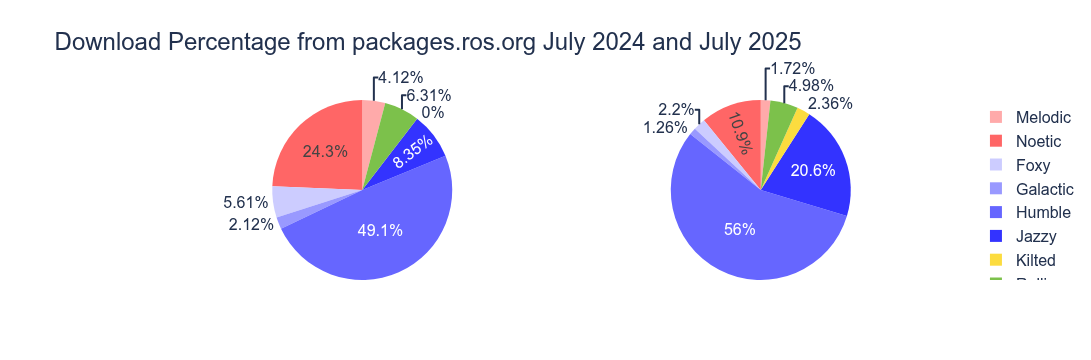

In [86]:
# Generate side by side plots of distros
temp = distro_df[distro_df[this_year]>=1].copy()
new_names = [a[0].upper()+a[1:] for a in temp["name"]]
print(new_names)
temp["name"] = pd.Series(data=new_names,copy=False,index=temp["name"].index)

new_row = pd.DataFrame(data=[{"name":"All Other Distros","2023":all_other_this,"2022":all_other_last},
                             {"name":"Python Pkgs","2023":everything_else_this,"2022":everything_else_last}])
temp = pd.concat([temp, new_row], ignore_index=True)
print(temp["name"])
print(temp)
print(temp[last_year].sum())
print(temp[this_year].sum())

colors ={"noetic": 'rgba(255,0,0,0.4)',
         "melodic": 'rgba(255,0,0,0.4)',
         "kinetic": 'rgba(255,0,0,0.4)',
         "dashing": 'rgba(255,0,0,0.4)',
         "eloquent": 'rgba(255,0,0,0.4)',
         "foxy": 'rgba(255,0,0,0.4)',         
         "galactic": 'rgba(255,0,0,0.4)',
         "humble": 'rgba(255,0,0,0.4)',
         "iron": 'rgba(255,0,0,0.4)',
         "jazzy": 'rgba(255,0,0,0.4)',
         "kilted": 'rgba(255,0,0,0.4)',
         "rolling": 'rgba(255,0,0,0.4)',
        }

#title={
#    'text': "Plot Title",
#    'xanchor': 'center',
#    'yanchor': 'top'}
title ={
    'text': "Plot Title",
    'y':0.9,
    'x':0.5,
    'xanchor': 'center',
    'yanchor': 'bottom'}

trace1 = go.Pie(values= temp[last_year], labels = temp["name"],domain=dict(x=[0, 0.5]),title="",sort= False)
trace2 = go.Pie(values= temp[this_year], labels = temp["name"],domain=dict(x=[0.5,1.0]),title="", sort=False)
layout = go.Layout(title="Download Percentage from packages.ros.org July 2024 and July 2025")
data = [trace1,trace2]
fig = go.Figure(data=data, layout=layout)


fig.update_layout(
    font_family="Arial",
    font_color="#22314E",
    font_size=16,
    title_font_size = 24,
    title_font_family="Arial",
    title_font_color="#22314E"
)

fig.update_traces(marker=dict(colors=['#FFAAAA','#FF6666','#CCCCFF','#9999FF',
                                      '#6666FF','#3333FF','#fcdc3f',"#7cc14b","#EE00FF","#FF00FF"]))

fig.show()


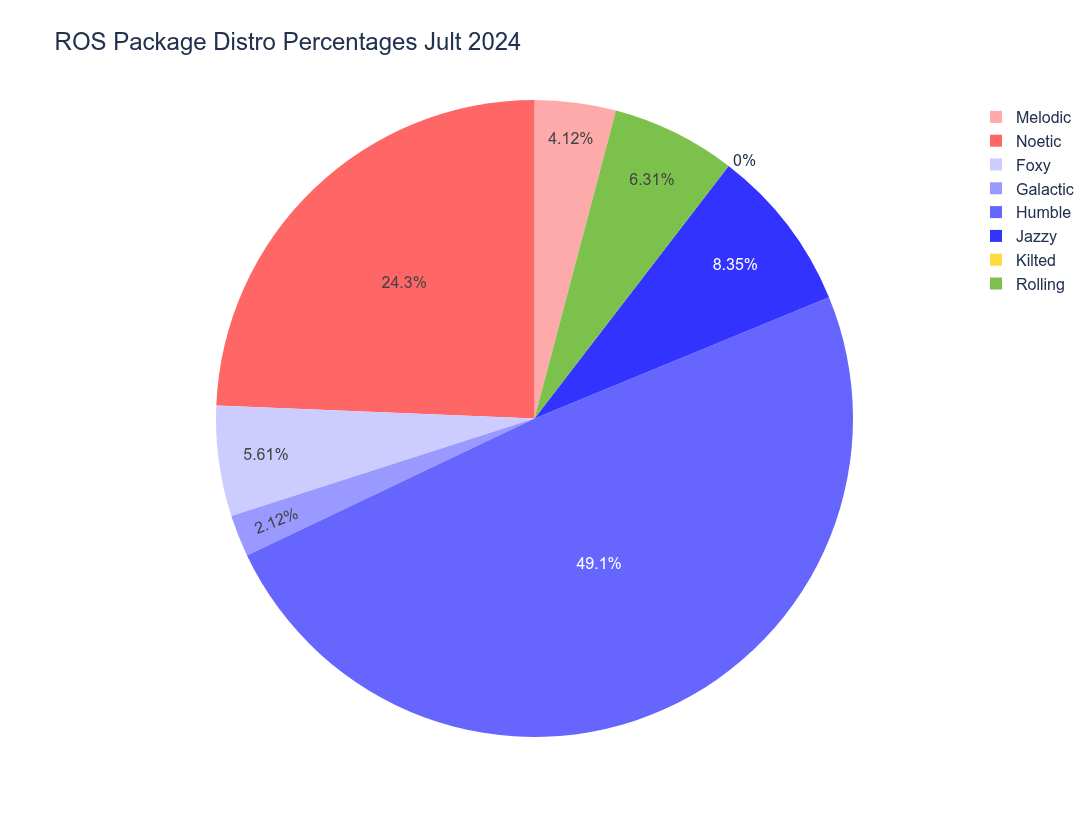

In [55]:
trace1 = go.Pie(values= temp[last_year], labels = temp["name"],title="",sort= False)
layout = go.Layout(title="ROS Package Distro Percentages {0} {1}".format(last_month,last_year))
fig = go.Figure(data=trace1, layout=layout)


fig.update_layout(
    font_family="Arial",
    font_color="#22314E",
    font_size=16,
    title_font_size = 24,
    title_font_family="Arial",
    title_font_color="#22314E",
    width=1200,
    height=800
)

fig.update_traces(marker=dict(colors=['#FFAAAA','#FF6666','#CCCCFF','#9999FF',
                                      '#6666FF','#3333FF','#fcdc3f',"#7cc14b","#FF00FF","#0000FF"]))

fig.show()


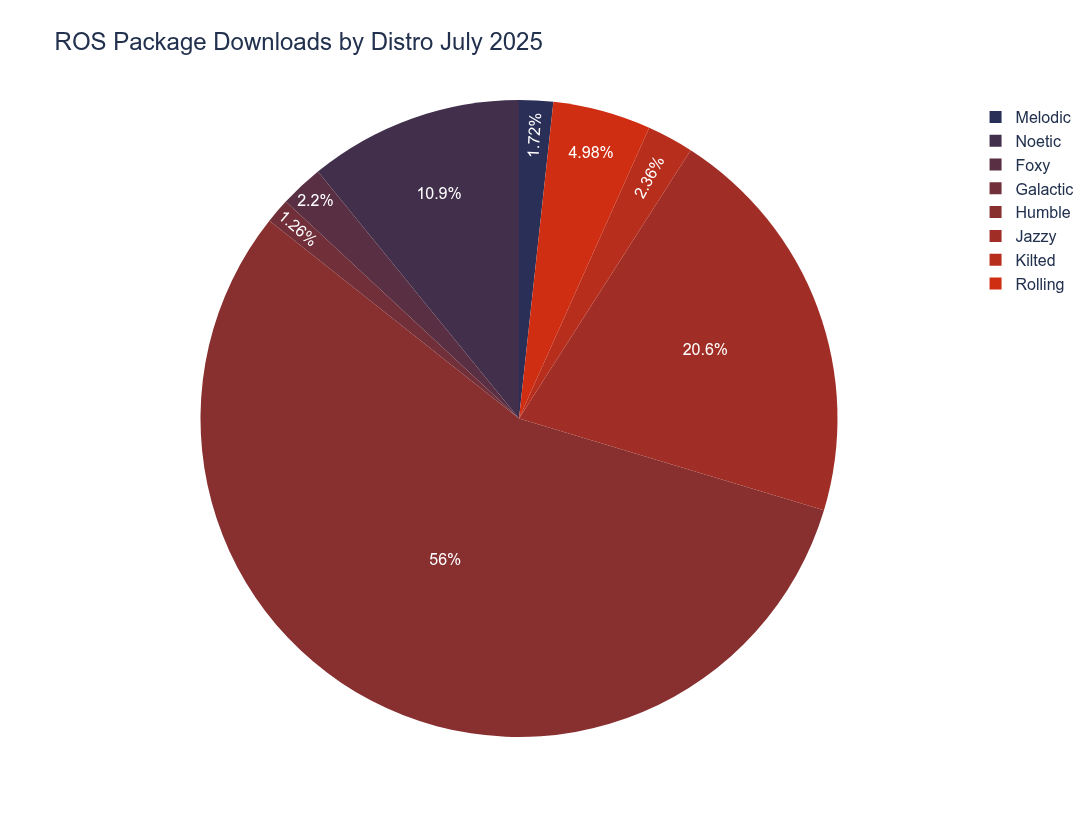

In [53]:
trace2 = go.Pie(values= temp[this_year], labels = temp["name"],title="",sort= False)
layout = go.Layout(title="ROS Package Downloads by Distro {0} {1}".format(this_month,this_year))
fig = go.Figure(data=trace2, layout=layout)


fig.update_layout(
    font_family="Arial",
    font_color="#22314E",
    font_size=16,
    title_font_size = 24,
    title_font_family="Arial",
    title_font_color="#22314E",
    width=1200,
    height=800
)

fig.update_traces(marker=dict(colors=["#292f56",
"#412f4c",
"#592f43",
"#702f39",
"#882f30",
"#a02e26",
"#b82e1d",
"#cf2e13",
"#e72e0a",
"#ff2e00",]))


fig.show()


In [49]:
fig.update_layout?


Signature: fig.update_layout(dict1=None, overwrite=False, **kwargs) -> 'Figure'
Docstring:
Update the properties of the figure's layout with a dict and/or with
keyword arguments.

This recursively updates the structure of the original
layout with the values in the input dict / keyword arguments.

Parameters
----------
dict1 : dict
    Dictionary of properties to be updated
overwrite: bool
    If True, overwrite existing properties. If False, apply updates
    to existing properties recursively, preserving existing
    properties that are not specified in the update operation.
kwargs :
    Keyword/value pair of properties to be updated

Returns
-------
BaseFigure
    The Figure object that the update_layout method was called on
File:      ~/Code/ros_metrics_analysis/notebooks/metrics/lib/python3.13/site-packages/plotly/graph_objs/_figure.py
Type:      method

In [ ]:
# Download percentages by year
temp["diff"]=temp[this_year]-temp[last_year]
temp = arch_df[arch_os_df[this_year]>0.00001]

trace1 = go.Pie(values= temp[this_year], labels = temp["name"],domain=dict(x=[0.5, 1]),title=this_year)
trace2 = go.Pie(values= temp[last_year], labels = temp["name"],domain=dict(x=[0.0,0.5]),title=last_year)

layout = go.Layout(title="ROS Packages Downloaded By Architecture - {0} {1} vs {2} {3}".format(last_month,last_year,this_year,this_month))
data = [trace1, trace2]
fig = go.Figure(data=data, layout=layout)
fig.show()

In [ ]:
fig = px.bar(distro_df, x="name", y=["2023", "2022"], title="Wide-Form Input")
fig.show()

In [ ]:
fname = "../data/march_2020.txt"
stats_mar_2020 = process_package_dump(fname,"3/2020")
fname = "../data/march_2021.txt"
stats_mar_2021 = process_package_dump(fname,"3/2021")

joined_distro = join_stats([stats_mar_2020["distro"],stats_mar_2021["distro"]])
mar_distro_df = pd.DataFrame(data=joined_distro)
mar_distro_df.to_csv("march_distro.csv")
mar_distro_df.head()
stats_mar_2021 = process_package_dump(fname,"3/2021")

In [ ]:
temp = mar_distro_df[mar_distro_df["7/2021"]>0.5]

trace1 = go.Pie(values= temp["7/2020"], labels = temp["name"],domain=dict(x=[0.5,1.0]),title="7/2020")
trace2 = go.Pie(values= temp["7/2021"], labels = temp["name"],domain=dict(x=[0, 0.5]),title="7/2021")

layout = go.Layout(title="ROS Index Download Percentage: March 2020 vs. March 2021",)
data = [trace1, trace2]
fig = go.Figure(data=data, layout=layout)
fig.show()


In [ ]:
cd ../data/


In [ ]:
stats_this